### Improting packages

In [45]:
# Importing libarires 

library("igraph")

### Reading input files

In [46]:
# Reading the graph from the file into an edge list
edges <- read.csv("./data/fb-pages-artist.edges", header = FALSE, col.names = c("from", "to"))
nodes <- read.csv("./data/fb-pages-artist.nodes", header = TRUE)

nodes$new_id <- as.character(nodes$new_id)
edges$from <- as.character(edges$from)
edges$to <- as.character(edges$to)

# Remove edges where either endpoint is missing from nodes
valid_ids <- nodes$new_id
edges <- edges[edges$from %in% valid_ids & edges$to %in% valid_ids,]

# Creating the graph from the edge list
g <- graph_from_data_frame(edges, directed = FALSE, vertices = nodes[, c("new_id", "name")])


### Graph properties

In [47]:
cat("Vertices:", vcount(g), "\n")
cat("Edges:", ecount(g), "\n")
cat("Density:", format(edge_density(g), scientific = FALSE), "\n")
cat("Maximum degree:", max(igraph::degree(g)), "\n")
cat("Average degree:", round(mean(igraph::degree(g)), 2), "\n")
cat("Minimum degree:", min(igraph::degree(g)), "\n")

Vertices: 50492 
Edges: 819096 
Density: 0.0006425816 
Maximum degree: 1468 
Average degree: 32.44 
Minimum degree: 1 


### Simpyfing the graph

In [48]:
# removing vertices with degree less than 3

g <- delete_vertices(g, V(g)[degree(g) < 1000])

cat("\nVertices (post degree filtering):", vcount(g),"\nEdges (post degree filtering):", ecount(g), "\n")



Vertices (post degree filtering): 23 
Edges (post degree filtering): 80 


### Running igraph functions

In [49]:
cat("Clustering coefficient:", transitivity(g), "\n")

Clustering coefficient: 0.2284264 


In [50]:
g.ap <- articulation_points(g)
cat("Articulation points:", g.ap, "\n")

Articulation points:  


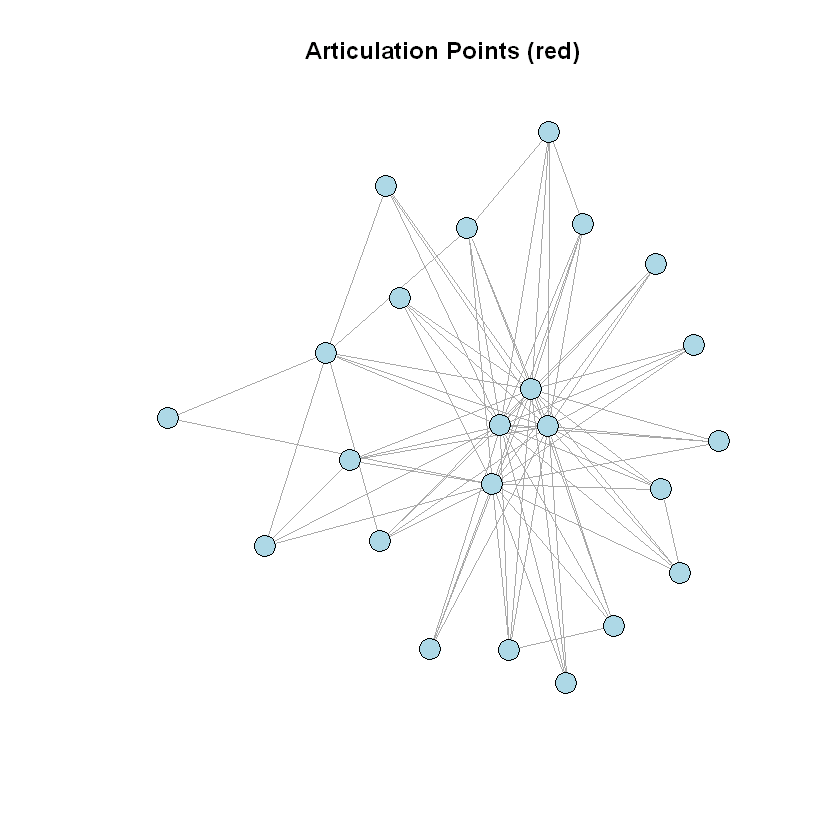

In [51]:
V(g)$color <- "lightblue"
V(g)[g.ap]$color <- "red"
plot(g,
     vertex.color = V(g)$color,
     vertex.size = 8,
     vertex.label = NA,
     main = "Articulation Points (red)")

              name coreness
          Skrillex        5
 Justin Timberlake        5
      David Guetta        5
      Taylor Swift        5
          PLASTIKO        5
     Justin Bieber        5
            Eminem        5
    Christin Stark        5
    Jonny Zywiciel        5
           Beyoncé        5


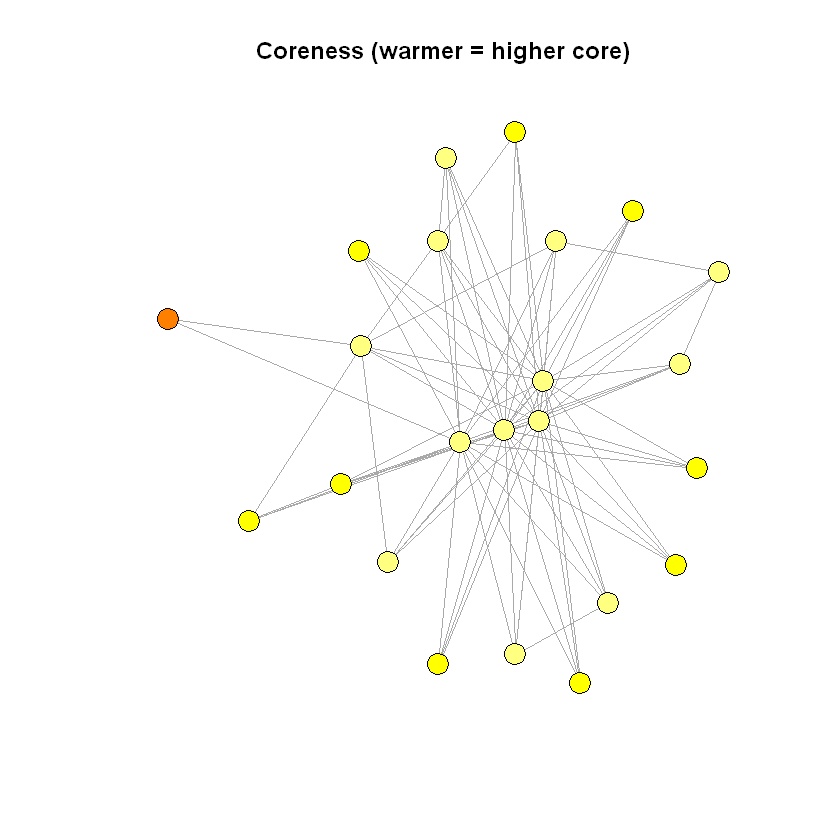

In [52]:
g.coreness <- coreness(g)
node_names <- V(g)$name

result <- data.frame(name = node_names, coreness = g.coreness)
result <- result[order(result$coreness, decreasing = TRUE), ]

print(head(result, 10), row.names = FALSE)

V(g)$color <- g.coreness
plot(g,
     vertex.color = heat.colors(max(g.coreness) + 1)[g.coreness + 1],
     vertex.size = 8,
     vertex.label = NA,
     main = "Coreness (warmer = higher core)")

Top 10 by eigenvector centrality:
           name eigenvector
    Yuna Alvara   1.0000000
 Christin Stark   0.8837634
 Jonny Zywiciel   0.8837634
       PLASTIKO   0.6803391
       Skrillex   0.4920397
   David Guetta   0.4797322
         Eminem   0.4349685
   Taylor Swift   0.4278859
        Beyoncé   0.4278859
  Justin Bieber   0.4278859


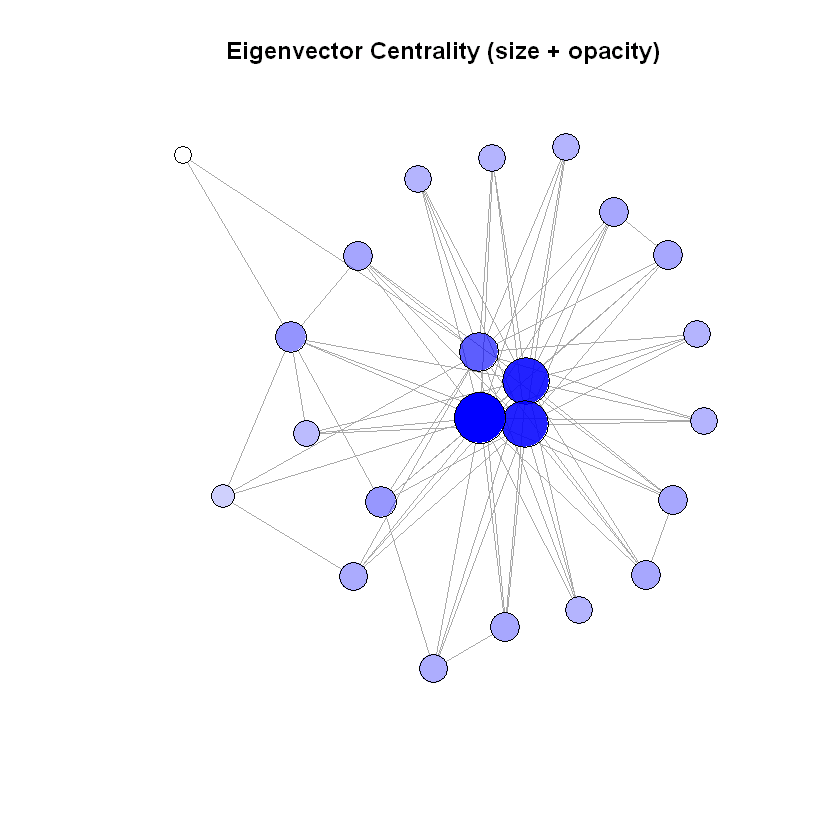

In [53]:
g.eig <- eigen_centrality(g)$vector
eig_df <- data.frame(name = node_names, eigenvector = g.eig)
eig_df <- eig_df[order(eig_df$eigenvector, decreasing = TRUE), ]
cat("Top 10 by eigenvector centrality:\n")
print(head(eig_df, 10), row.names = FALSE)


plot(g,
     vertex.color = rgb(0, 0, 1, alpha = (g.eig - min(g.eig)) / (max(g.eig) - min(g.eig))),
     vertex.size = 5 + 15 * (g.eig / max(g.eig)),
     vertex.label = NA,
     main = "Eigenvector Centrality (size + opacity)")

Top 10 by PageRank:
           name   pagerank
    Yuna Alvara 0.11626001
 Jonny Zywiciel 0.10539424
 Christin Stark 0.10539424
       PLASTIKO 0.09698227
       Skrillex 0.05097858
   David Guetta 0.03745409
        Rihanna 0.03242179
  Martin Garrix 0.03216908
       Hardwell 0.03203762
        Beyoncé 0.03201069


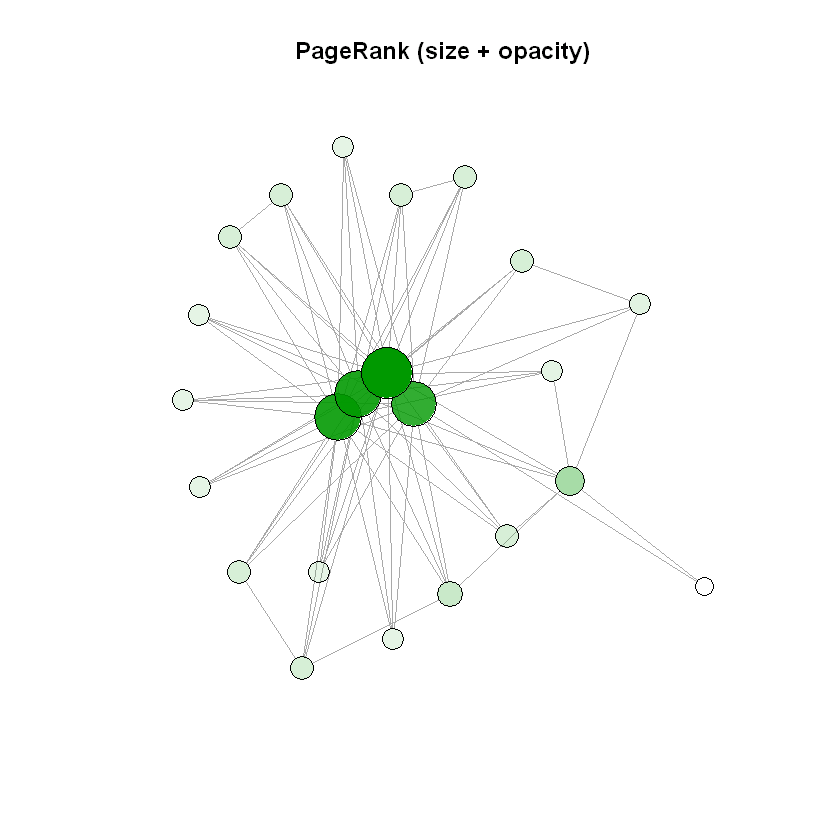

In [54]:
g.pr <- page_rank(g)$vector
pr_df <- data.frame(name = node_names, pagerank = g.pr)
pr_df <- pr_df[order(pr_df$pagerank, decreasing = TRUE), ]
cat("Top 10 by PageRank:\n")
print(head(pr_df, 10), row.names = FALSE)

plot(g,
     vertex.color = rgb(0, 0.6, 0, alpha = (g.pr - min(g.pr)) / (max(g.pr) - min(g.pr))),
     vertex.size = 5 + 15 * (g.pr / max(g.pr)),
     vertex.label = NA,
     main = "PageRank (size + opacity)")

In [55]:
cat("Assortativity:", assortativity_degree(g), "\n")

Assortativity: -0.7241091 


Number of communities: 4 
Community sizes
 2  1  3  4 
13  4  4  2 


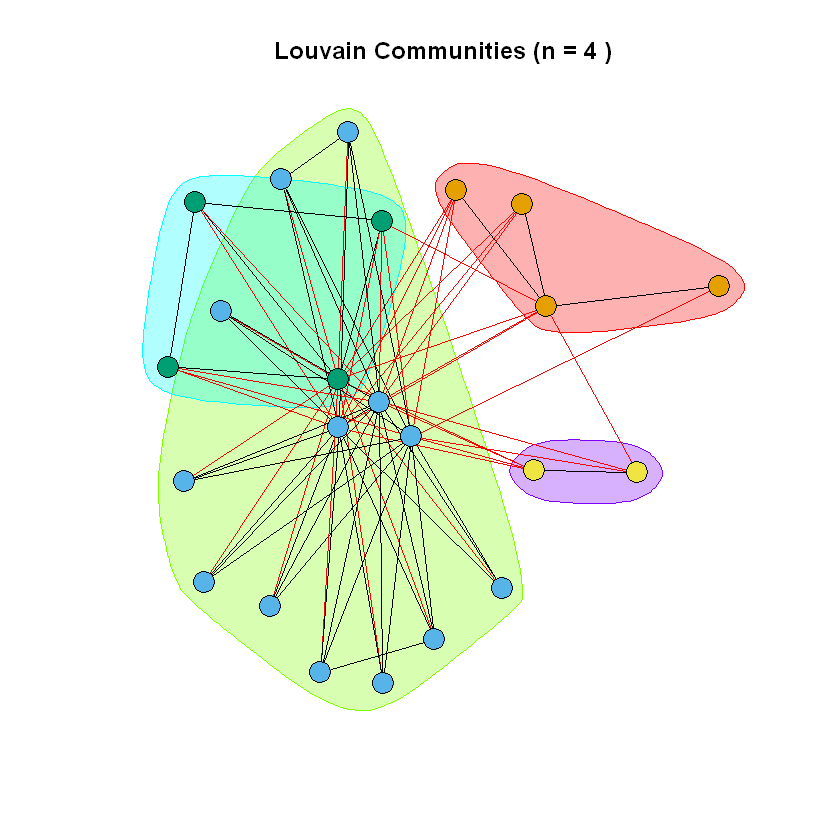

In [56]:
g.communities <- cluster_louvain(g)
cat("Number of communities:", length(g.communities), "\n")
print(sort(sizes(g.communities), decreasing = TRUE))

plot(g.communities, g,
     vertex.size = 8,
     vertex.label = NA,
     main = paste("Louvain Communities (n =", length(g.communities), ")"))


In [57]:
# g.ecc <- eccentricity(g)
# ecc_df <- data.frame(name = node_names, eccentricity = g.ecc)
# ecc_df <- ecc_df[order(ecc_df$eccentricity), ]
# cat("Top 10 most central nodes:\n")
# print(head(ecc_df, 10), row.names = FALSE)

In [58]:
# cat("Average path length:", mean_distance(g), "\n")

In [59]:
# g.bridges <- bridges(g)
# cat("Number of bridges:", length(g.bridges), "\n")


--- 1. Hub & Authority Scores ---
Top 10 Hub scores:
              name       hub
       Yuna Alvara 1.0000000
    Christin Stark 0.8837634
    Jonny Zywiciel 0.8837634
          PLASTIKO 0.6803391
          Skrillex 0.4920397
      David Guetta 0.4797322
            Eminem 0.4349685
     Justin Bieber 0.4278859
 Justin Timberlake 0.4278859
      Taylor Swift 0.4278859
Top 10 Authority scores:
           name authority
    Yuna Alvara 1.0000000
 Christin Stark 0.8837634
 Jonny Zywiciel 0.8837634
       PLASTIKO 0.6803391
       Skrillex 0.4920397
   David Guetta 0.4797322
         Eminem 0.4349685
   Taylor Swift 0.4278859
  Justin Bieber 0.4278859
        Beyoncé 0.4278859


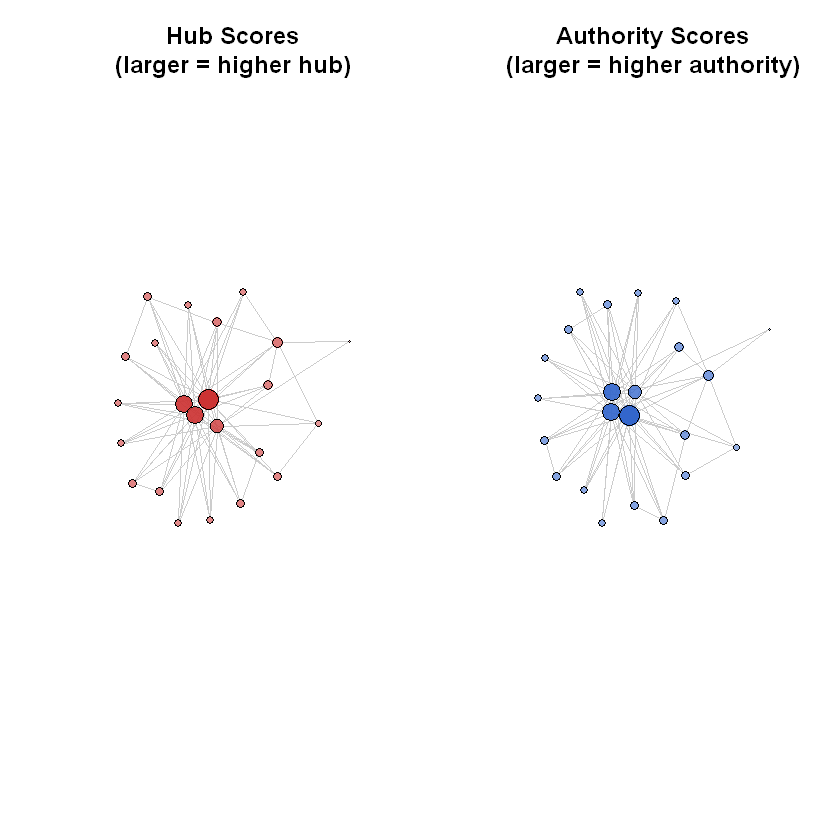

In [60]:
# ============================================================
# Advanced igraph Analysis - 10 Functions with Visualizations
# ============================================================
# Prerequisites: igraph must be installed and a graph object
# named 'g' must exist in your environment.
# library(igraph)

node_names <- V(g)$name

# Helper: normalize a vector to [0,1] for visual scaling
norm01 <- function(x) {
  r <- range(x, na.rm = TRUE)
  if (diff(r) == 0) return(rep(0.5, length(x)))
  (x - r[1]) / diff(r)
}

# ============================================================
# 1. Hub and Authority Scores (HITS Algorithm)
# ============================================================
cat("\n--- 1. Hub & Authority Scores ---\n")
g.hits   <- hits_scores(g)
hub_df   <- data.frame(name = node_names, hub       = g.hits$hub)
auth_df  <- data.frame(name = node_names, authority = g.hits$authority)
hub_df   <- hub_df[order(hub_df$hub,             decreasing = TRUE), ]
auth_df  <- auth_df[order(auth_df$authority,     decreasing = TRUE), ]
cat("Top 10 Hub scores:\n");       print(head(hub_df,  10), row.names = FALSE)
cat("Top 10 Authority scores:\n"); print(head(auth_df, 10), row.names = FALSE)

# Plot: side-by-side hub vs authority (node size = score)
par(mfrow = c(1, 2), bg = "white")
plot(g,
     vertex.size  = 3 + 15 * norm01(g.hits$hub),
     vertex.color = rgb(0.8, 0.2, 0.2,
                        alpha = 0.4 + 0.6 * norm01(g.hits$hub)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Hub Scores\n(larger = higher hub)")
plot(g,
     vertex.size  = 3 + 15 * norm01(g.hits$authority),
     vertex.color = rgb(0.2, 0.4, 0.8,
                        alpha = 0.4 + 0.6 * norm01(g.hits$authority)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Authority Scores\n(larger = higher authority)")
par(mfrow = c(1, 1))


--- 2. Constraint (Structural Holes) ---
Top 10 least constrained (structural hole bridgers):
            name constraint
        PLASTIKO 0.07329102
  Christin Stark 0.14355453
  Jonny Zywiciel 0.14355453
     Yuna Alvara 0.18478661
        Skrillex 0.24397184
    David Guetta 0.26500064
          Eminem 0.26549599
         Rihanna 0.27431119
      Katy Perry 0.27747299
 Michael Jackson 0.27747299


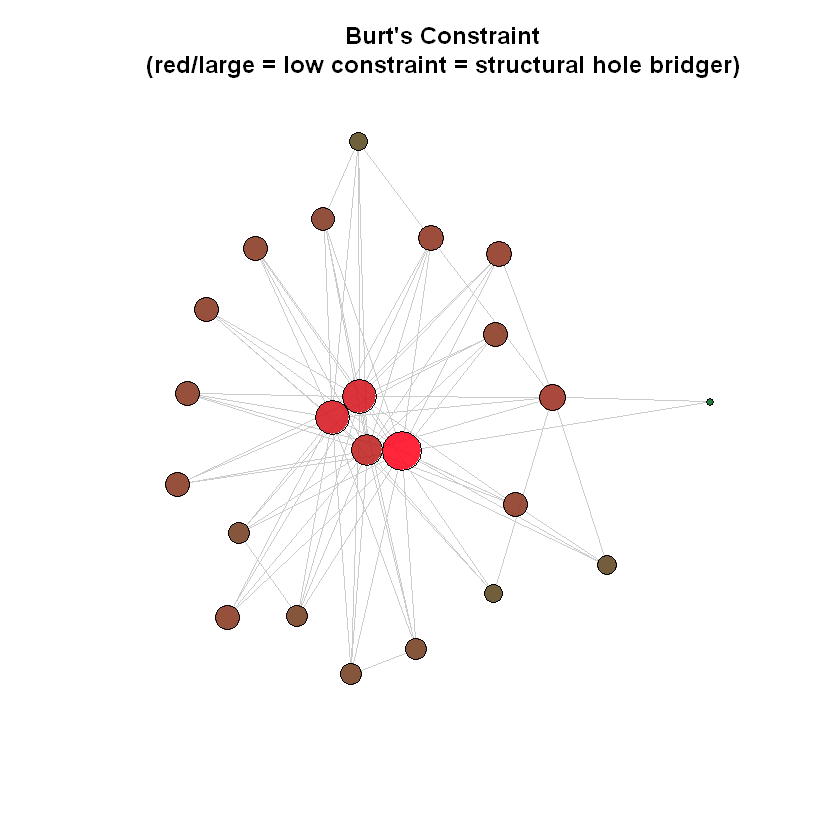

In [61]:
# ============================================================
# 2. Constraint — Burt's Structural Holes
# ============================================================
cat("\n--- 2. Constraint (Structural Holes) ---\n")
g.constraint <- constraint(g)
const_df <- data.frame(name = node_names, constraint = g.constraint)
const_df <- const_df[order(const_df$constraint, na.last = TRUE), ]
cat("Top 10 least constrained (structural hole bridgers):\n")
print(head(const_df, 10), row.names = FALSE)

# Plot: low constraint (red) = bridging nodes = structural power
constraint_safe <- ifelse(is.na(g.constraint), 1, g.constraint)
plot(g,
     vertex.size  = 3 + 12 * (1 - norm01(constraint_safe)),
     vertex.color = rgb(1 - norm01(constraint_safe),
                        norm01(constraint_safe) * 0.4,
                        0.1, alpha = 0.85),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Burt's Constraint\n(red/large = low constraint = structural hole bridger)",
     bg           = "white")


--- 3. Neighborhood Size (k=1 and k=2) ---


Top 10 by 2-hop neighborhood size:
              name k1 k2
          Skrillex  8 22
 Justin Timberlake  5 22
      David Guetta  6 22
      Taylor Swift  5 22
     Justin Bieber  5 22
            Eminem  5 22
    Christin Stark 18 22
        Katy Perry  4 22
    Jonny Zywiciel 18 22
     Calvin Harris  4 22


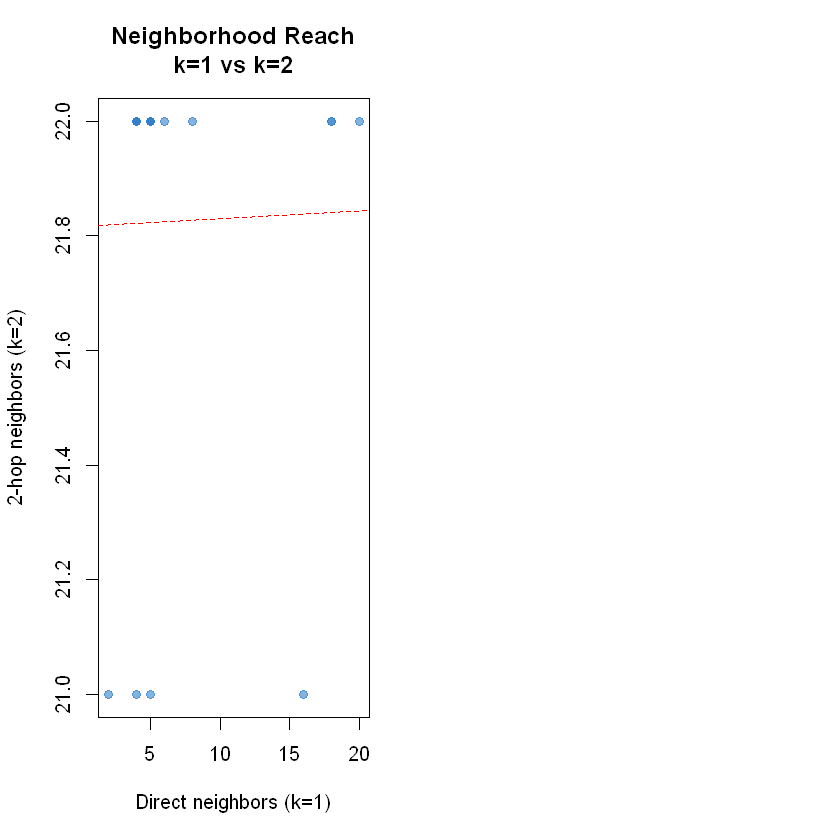

In [62]:
# ============================================================
# 3. Neighborhood Size at k = 1 and k = 2
# ============================================================
cat("\n--- 3. Neighborhood Size (k=1 and k=2) ---\n")
k1 <- sapply(V(g), function(v) length(neighbors(g, v, mode = "all")))
k2 <- sapply(V(g), function(v) length(ego(g, order = 2, nodes = v)[[1]]) - 1)
neigh_df <- data.frame(name = node_names, k1 = k1, k2 = k2)
neigh_df <- neigh_df[order(neigh_df$k2, decreasing = TRUE), ]
cat("Top 10 by 2-hop neighborhood size:\n")
print(head(neigh_df, 10), row.names = FALSE)

# Plot: k1 vs k2 scatter + graph colored by k2
par(mfrow = c(1, 2), bg = "white")
plot(k1, k2,
     xlab = "Direct neighbors (k=1)",
     ylab = "2-hop neighbors (k=2)",
     main = "Neighborhood Reach\nk=1 vs k=2",
     pch  = 19,
     col  = rgb(0.2, 0.5, 0.8, 0.6),
     bg   = "white")
abline(lm(k2 ~ k1), col = "red", lty = 2)


--- 4. Local Clustering Coefficient ---
Top 10 by local clustering coefficient:
              name  local_cc
             Diplo 0.8333333
     Martin Garrix 0.8000000
 Justin Timberlake 0.6000000
      Taylor Swift 0.6000000
     Justin Bieber 0.6000000
           Beyoncé 0.6000000
      David Guetta 0.5333333
            Eminem 0.5000000
     Calvin Harris 0.5000000
          Hardwell 0.5000000
Global clustering coefficient: 0.2284264 


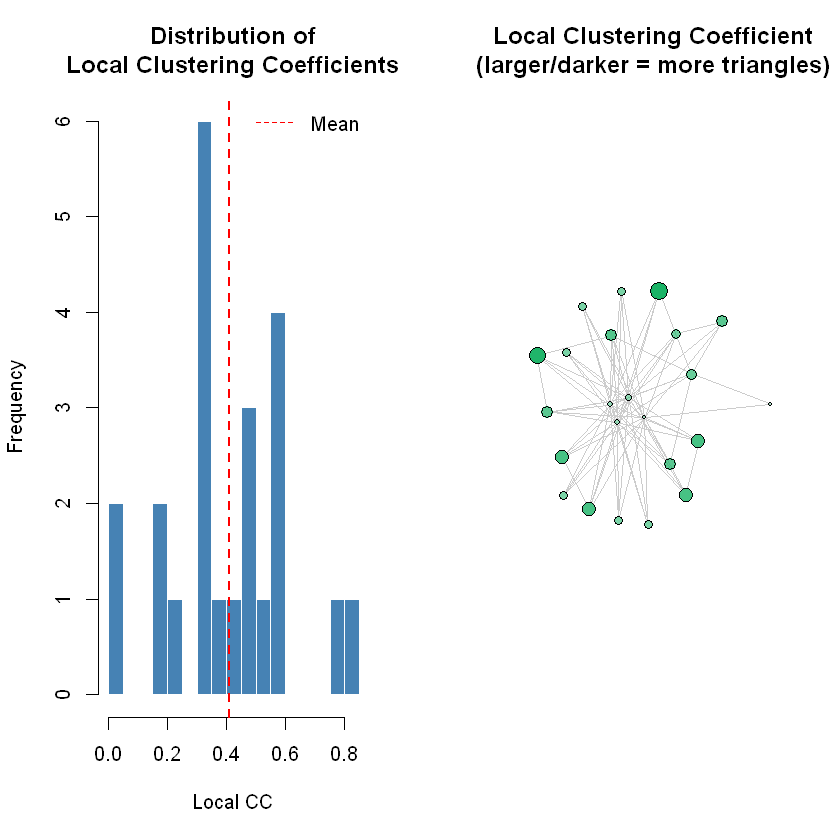

In [63]:
# ============================================================
# 4. Local Clustering Coefficient
# ============================================================
cat("\n--- 4. Local Clustering Coefficient ---\n")
g.local_cc <- transitivity(g, type = "local")
lcc_df <- data.frame(name = node_names, local_cc = g.local_cc)
lcc_df <- lcc_df[order(lcc_df$local_cc, decreasing = TRUE, na.last = TRUE), ]
cat("Top 10 by local clustering coefficient:\n")
print(head(lcc_df, 10), row.names = FALSE)
cat("Global clustering coefficient:", transitivity(g), "\n")

# Plot: histogram + graph colored by local CC
par(mfrow = c(1, 2), bg = "white")
hist(g.local_cc,
     breaks = 20,
     col    = "steelblue",
     border = "white",
     main   = "Distribution of\nLocal Clustering Coefficients",
     xlab   = "Local CC",
     ylab   = "Frequency")
abline(v = mean(g.local_cc, na.rm = TRUE), col = "red", lty = 2, lwd = 2)
legend("topright", legend = "Mean", col = "red", lty = 2, bty = "n")

lcc_safe <- ifelse(is.na(g.local_cc), 0, g.local_cc)
plot(g,
     vertex.size  = 3 + 12 * norm01(lcc_safe),
     vertex.color = rgb(0.1, 0.7, 0.4,
                        alpha = 0.3 + 0.7 * norm01(lcc_safe)),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Local Clustering Coefficient\n(larger/darker = more triangles)")
par(mfrow = c(1, 1))



--- 5. Edge Connectivity (Adhesion) ---
Edge connectivity: 2 — need to remove 2 edge(s) to disconnect


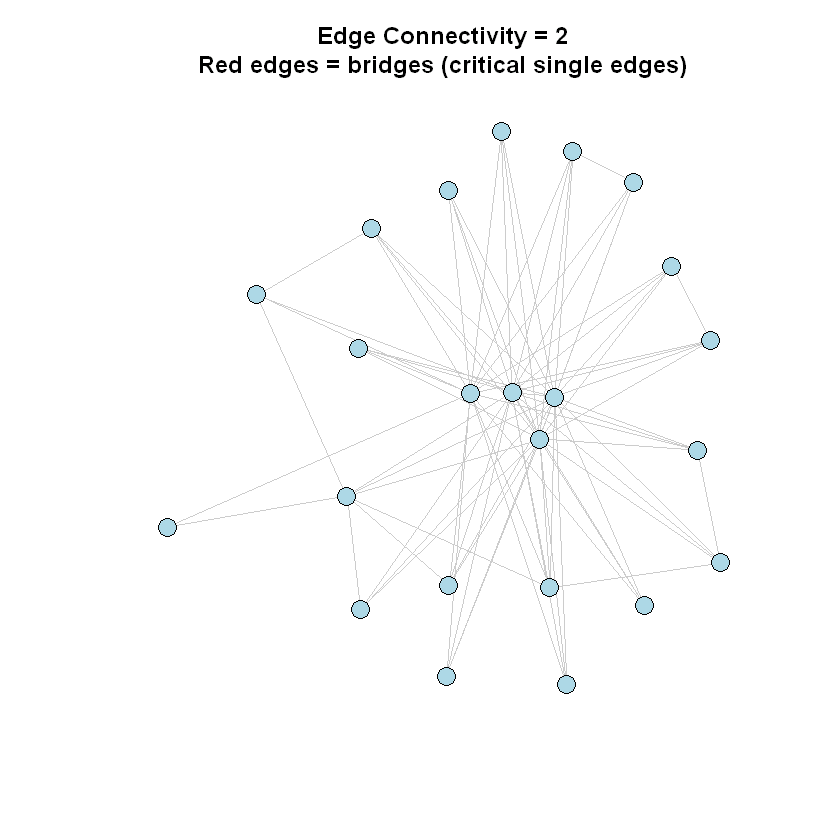

In [64]:
# ============================================================
# 5. Edge Connectivity (Adhesion)
# ============================================================
cat("\n--- 5. Edge Connectivity (Adhesion) ---\n")
g.adhesion <- edge_connectivity(g)
cat("Edge connectivity:", g.adhesion,
    "— need to remove", g.adhesion, "edge(s) to disconnect\n")

# Plot: highlight bridges (if any) alongside edge connectivity info
g.bridges <- bridges(g)
edge_cols  <- rep("gray80", ecount(g))
edge_widths <- rep(0.8,     ecount(g))
if (length(g.bridges) > 0) {
  edge_cols[g.bridges]   <- "red"
  edge_widths[g.bridges] <- 3
}
plot(g,
     vertex.size  = 7,
     vertex.color = "lightblue",
     vertex.label = NA,
     edge.color   = edge_cols,
     edge.width   = edge_widths,
     main         = paste0("Edge Connectivity = ", g.adhesion,
                            "\nRed edges = bridges (critical single edges)"),
     bg           = "white")


--- 6. Vertex Connectivity (Cohesion) ---
Vertex connectivity: 2 — need to remove 2 node(s) to disconnect


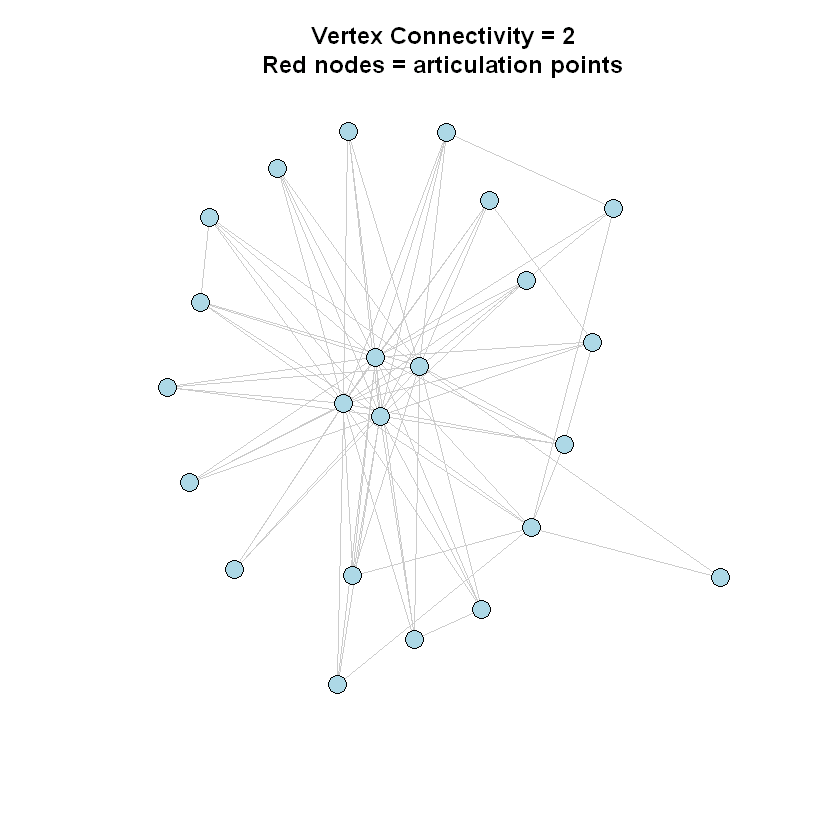

In [65]:
# ============================================================
# 6. Vertex Connectivity (Cohesion)
# ============================================================
cat("\n--- 6. Vertex Connectivity (Cohesion) ---\n")
g.cohesion <- vertex_connectivity(g)
cat("Vertex connectivity:", g.cohesion,
    "— need to remove", g.cohesion, "node(s) to disconnect\n")

g.ap <- articulation_points(g)
V(g)$color <- "lightblue"
if (length(g.ap) > 0) V(g)[g.ap]$color <- "red"

plot(g,
     vertex.color = V(g)$color,
     vertex.size  = 7,
     vertex.label = NA,
     edge.color   = "gray80",
     main         = paste0("Vertex Connectivity = ", g.cohesion,
                            "\nRed nodes = articulation points"),
     bg           = "white")

In [66]:
# ============================================================
# 7. Reciprocity
# ============================================================
cat("\n--- 7. Reciprocity ---\n")
g.recip <- reciprocity(g)
cat("Reciprocity:", g.recip, "\n")
if (is_directed(g)) {
  cat("Graph is directed — reciprocity is meaningful\n")
} else {
  cat("Graph is undirected — reciprocity = 1.0 by definition\n")
  cat("Tip: reciprocity is most informative on directed graphs\n")
}


--- 7. Reciprocity ---
Reciprocity: 1 
Graph is undirected — reciprocity = 1.0 by definition
Tip: reciprocity is most informative on directed graphs



--- 8. Motif Census (size=3 triads) ---
Triad motif counts:
 motif_id count
        3   608
        4    60


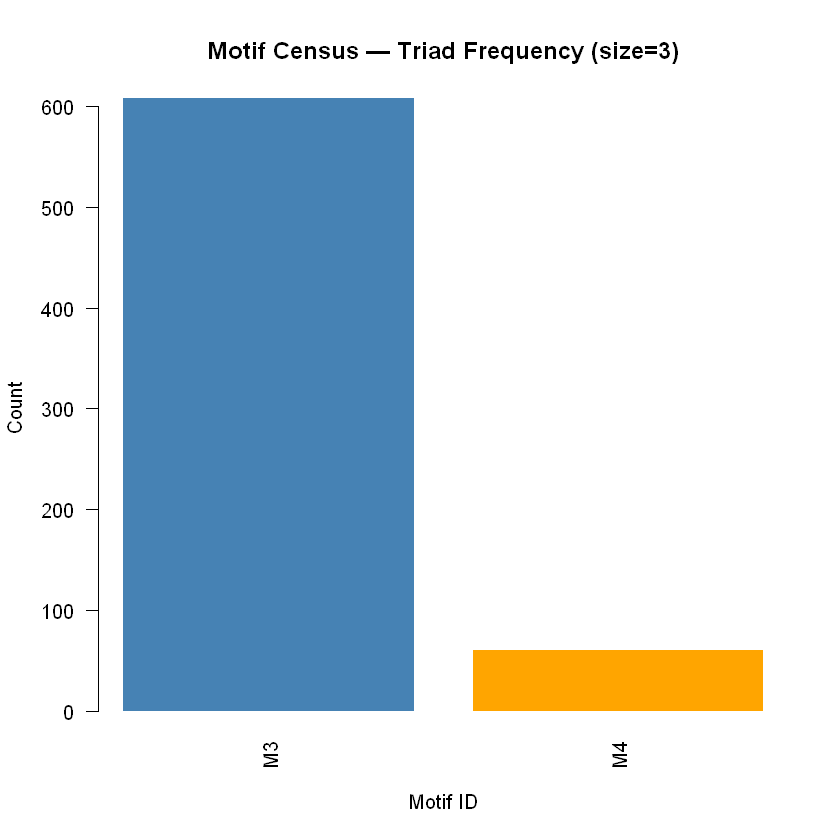

In [67]:
# ============================================================
# 8. Motif Census (Triad Counts)
# ============================================================
cat("\n--- 8. Motif Census (size=3 triads) ---\n")
g.motifs <- motifs(g, size = 3)
motif_df <- data.frame(motif_id = seq_along(g.motifs), count = g.motifs)
motif_df <- motif_df[!is.na(motif_df$count), ]
motif_df <- motif_df[order(motif_df$count, decreasing = TRUE), ]
cat("Triad motif counts:\n")
print(motif_df, row.names = FALSE)

# Plot: bar chart of motif frequencies
par(bg = "white")
barplot(motif_df$count,
        names.arg = paste0("M", motif_df$motif_id),
        col       = colorRampPalette(c("steelblue", "orange"))(nrow(motif_df)),
        border    = NA,
        main      = "Motif Census — Triad Frequency (size=3)",
        xlab      = "Motif ID",
        ylab      = "Count",
        las       = 2)


--- 9. Topological Sort ---
Graph is NOT a DAG — topological sort not applicable
Checking for cycles using girth()...
Girth (shortest cycle length): 3 


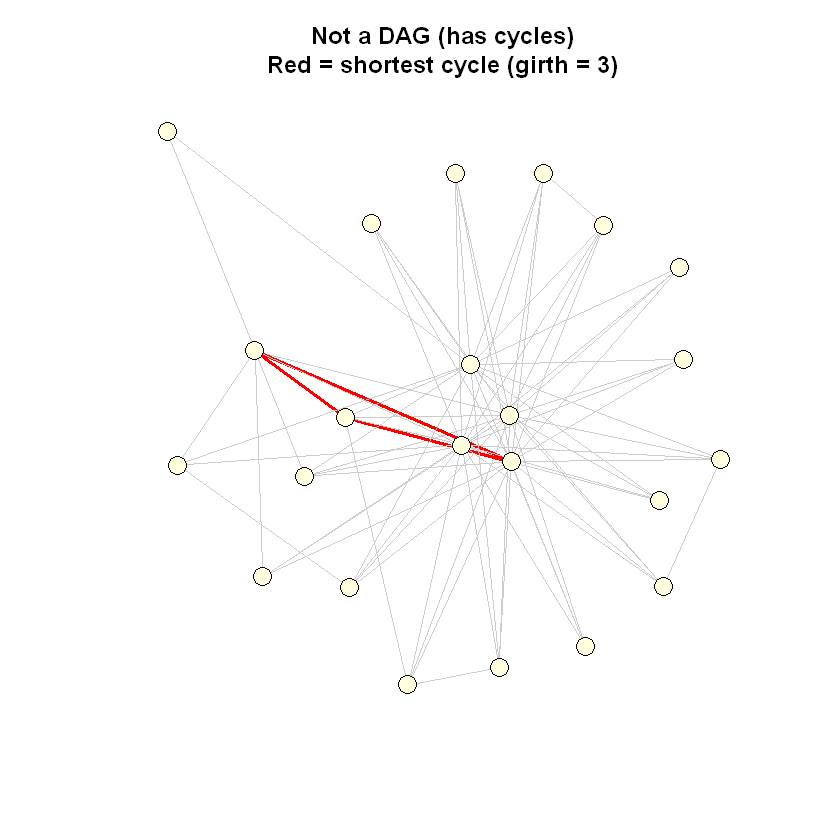

In [68]:
# ============================================================
# 9. Topological Sort (DAG check)
# ============================================================
cat("\n--- 9. Topological Sort ---\n")
if (is_dag(g)) {
  g.topo <- topo_sort(g)
  topo_order <- as.numeric(g.topo)
  cat("Graph IS a DAG — topological order (first 10):",
      head(topo_order, 10), "\n")

  # Color nodes by their topological rank
  topo_rank <- match(seq_len(vcount(g)), topo_order)
  plot(g,
       vertex.size  = 7,
       vertex.color = heat.colors(vcount(g))[topo_rank],
       vertex.label = NA,
       edge.color   = "gray60",
       edge.arrow.size = 0.4,
       layout       = layout_with_sugiyama(g)$layout,
       main         = "Topological Sort\n(warm = processed early)",
       bg           = "white")
} else {
  cat("Graph is NOT a DAG — topological sort not applicable\n")
  cat("Checking for cycles using girth()...\n")
  g.girth <- girth(g)
  cat("Girth (shortest cycle length):", g.girth$girth, "\n")

  # Plot: highlight the shortest cycle
  cycle_edges <- g.girth$circle
  e_cols <- rep("gray80", ecount(g))
  if (length(cycle_edges) > 1) {
    cycle_edge_ids <- get.edge.ids(g,
      as.vector(rbind(cycle_edges, c(cycle_edges[-1], cycle_edges[1]))))
    e_cols[cycle_edge_ids] <- "red"
  }
  plot(g,
       vertex.size  = 7,
       vertex.color = "lightyellow",
       vertex.label = NA,
       edge.color   = e_cols,
       edge.width   = ifelse(e_cols == "red", 3, 0.8),
       main         = paste0("Not a DAG (has cycles)\n",
                              "Red = shortest cycle (girth = ", g.girth$girth, ")"),
       bg           = "white")
}


--- 10. Laplacian Spectrum & Fiedler Value ---
Number of eigenvalues: 23 
Fiedler value (lambda2 — algebraic connectivity): 1.8603 
Spectral gap (lambda2 - lambda1):                 1.8603 
Interpretation: higher Fiedler = more robust / harder to disconnect

=== Analysis Complete ===


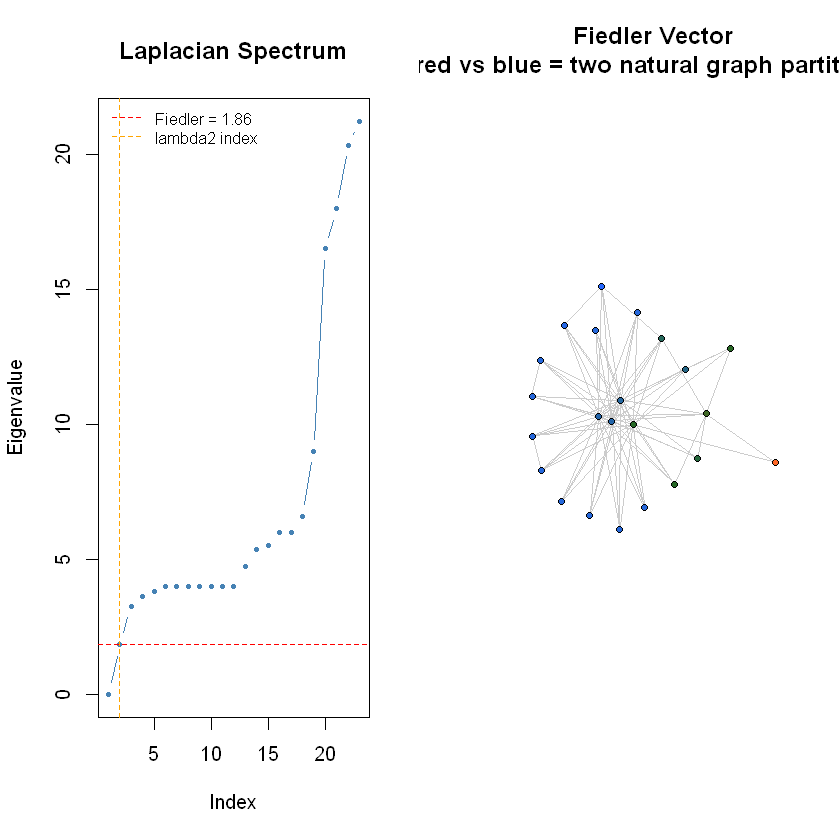

In [69]:

# ============================================================
# 10. Graph Laplacian Spectrum (Fiedler Value)
# ============================================================
cat("\n--- 10. Laplacian Spectrum & Fiedler Value ---\n")

# Compute on largest connected component to avoid 0 issues
g.comp   <- components(g)
g.giant  <- induced_subgraph(g,
               which(g.comp$membership == which.max(g.comp$csize)))

g.lap    <- laplacian_matrix(g.giant, sparse = FALSE)
g.eig    <- sort(eigen(g.lap)$values)
fiedler  <- g.eig[2]
spec_gap <- g.eig[2] - g.eig[1]

cat("Number of eigenvalues:", length(g.eig), "\n")
cat("Fiedler value (lambda2 — algebraic connectivity):", round(fiedler,  4), "\n")
cat("Spectral gap (lambda2 - lambda1):                ", round(spec_gap, 4), "\n")
cat("Interpretation: higher Fiedler = more robust / harder to disconnect\n")

# Plot: eigenvalue spectrum + Fiedler marker
par(mfrow = c(1, 2), bg = "white")
plot(seq_along(g.eig), g.eig,
     type = "b",
     pch  = 19,
     col  = "steelblue",
     cex  = 0.6,
     xlab = "Index",
     ylab = "Eigenvalue",
     main = "Laplacian Spectrum")
abline(h = fiedler, col = "red",    lty = 2, lwd = 1.5)
abline(v = 2,       col = "orange", lty = 2, lwd = 1.5)
legend("topleft",
       legend = c(paste0("Fiedler = ", round(fiedler, 3)), "lambda2 index"),
       col    = c("red", "orange"), lty = 2, bty = "n", cex = 0.8)

# Color giant component nodes by their Fiedler vector component
fiedler_vec <- eigen(g.lap)$vectors[, length(g.eig) - 1]
plot(g.giant,
     vertex.size  = 6,
     vertex.color = rgb(
       ifelse(fiedler_vec > 0, norm01(fiedler_vec[fiedler_vec > 0][
         match(seq_along(fiedler_vec),
               which(fiedler_vec > 0))]), 0),
       0.3,
       ifelse(fiedler_vec <= 0, norm01(-fiedler_vec[fiedler_vec <= 0][
         match(seq_along(fiedler_vec),
               which(fiedler_vec <= 0))]), 0),
       alpha = 0.85
     ),
     vertex.label = NA,
     edge.color   = "gray80",
     main         = "Fiedler Vector\n(red vs blue = two natural graph partitions)")
par(mfrow = c(1, 1))

cat("\n=== Analysis Complete ===\n")